# Update 2: Baseline Models

In [1]:
import pandas as pd
import numpy as np

# don't display warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('../data/full_clean.csv')
df.head()

,headline,stance,body,headline_length_words,headline_length_chars,body_length_words,body_length_chars,overlap_ratio,headline_coverage,body_coverage,headline_clean,body_clean,headline_tokens,body_tokens,overlap_clean,headline_coverage_clean,body_coverage_clean
0,Police find mass graves with at least '15 bodi...,unrelated,Danny Boyle is directing the untitled film\r\n...,19,115,195,1105,0.013605,0.111111,0.015267,police find mass graf least 15 body near mexic...,danny boyle directing untitled film seth rogen...,"{'43', 'town', 'least', 'mexico', 'clash', '15...","{'female', 'say', 'set', 'apple', 'naught', 'c...",0.000000,0.000,0.000000
1,Hundreds of Palestinians flee floods in Gaza a...,agree,Hundreds of Palestinians were evacuated from t...,11,65,429,2608,0.043478,0.909091,0.043668,hundred palestinian flee flood gaza israel ope...,hundred palestinian evacuated home sunday morn...,"{'dam', 'hundred', 'israel', 'gaza', 'flood', ...","{'including', 'home', 'last', 'near', 'forcing...",0.040462,0.875,0.040698
2,"Christian Bale passes on role of Steve Jobs, a...",unrelated,30-year-old Moscow resident was hospitalized w...,16,91,194,1123,0.028777,0.250000,0.031496,christian bale pass role steve job actor repor...,30 year old moscow resident hospitalized wound...,"{'bale', 'part', 'pass', 'actor', 'steve', 'fe...","{'surgery', 'say', 'convinced', 'executed', 'c...",0.000000,0.000,0.000000
3,HBO and Apple in Talks for $15/Month Apple TV ...,unrelated,(Reuters) - A Canadian soldier was shot at the...,14,82,80,504,0.027027,0.166667,0.031250,hbo apple talk 15 month apple tv streaming ser...,reuters canadian soldier shot canadian war mem...,"{'hbo', 'apple', 'service', '15', 'month', 'tv...","{'ran', 'according', 'report', 'war', 'abocar'...",0.000000,0.000,0.000000
4,Spider burrowed through tourist's stomach and ...,disagree,"Fear not arachnophobes, the story of Bunbury's...",10,63,612,3433,0.021605,0.700000,0.021807,spider burrowed tourist stomach chest,fear arachnophobes story bunbury spiderman mig...,"{'tourist', 'spider', 'burrowed', 'chest', 'st...","{'think', 'child', 'say', 'legend', 'none', 'a...",0.014706,0.600,0.014851


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75385 entries, 0 to 75384
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   headline                 75385 non-null  object 
 1   stance                   75385 non-null  object 
 2   body                     75385 non-null  object 
 3   headline_length_words    75385 non-null  int64  
 4   headline_length_chars    75385 non-null  int64  
 5   body_length_words        75385 non-null  int64  
 6   body_length_chars        75385 non-null  int64  
 7   overlap_ratio            75385 non-null  float64
 8   headline_coverage        75385 non-null  float64
 9   body_coverage            75385 non-null  float64
 10  headline_clean           75385 non-null  object 
 11  body_clean               75385 non-null  object 
 12  headline_tokens          75385 non-null  object 
 13  body_tokens              75385 non-null  object 
 14  overlap_clean         

## 1. Using undersampling to balance dataset

I want to try out different datasets and see which ones are performing good, for example undersampling to balance dataset, then using back translation and other augmentation method to oversample disagree stance.

In [ ]:
# Get class balanced dataset

min_n = df['stance'].value_counts().min()

df_balanced = df.groupby('stance', group_keys=False).apply(lambda x: x.sample(min_n, random_state=42)).reset_index(drop=True)

df_balanced.head()

,headline,stance,body,headline_length_words,headline_length_chars,body_length_words,body_length_chars,overlap_ratio,headline_coverage,body_coverage,headline_clean,body_clean,headline_tokens,body_tokens,overlap_clean,headline_coverage_clean,body_coverage_clean
0,'Zombie Cat' Claws Way Out Of Grave And Into O...,agree,Eight to go! Bart's owners accepted their loss...,11,55,234,1292,0.033113,0.454545,0.034483,zombie cat claw way grave heart,eight go bart owner accepted loss hit car buri...,"{'way', 'grave', 'cat', 'claw', 'heart', 'zomb...","{'think', 'despite', 'report', 'home', 'ground...",0.030612,0.500000,0.031579
1,Three Boobs Are Most Likely Two Boobs and a Lie,agree,The woman who claimed she had a third breast w...,10,47,17,79,0.090909,0.222222,0.133333,three boob likely two boob lie,woman claimed third breast lying story hoax,"{'lie', 'two', 'likely', 'boob', 'three'}","{'lying', 'breast', 'claimed', 'woman', 'third...",0.000000,0.000000,0.000000
2,"Calm down everyone, Banksy hasn't been arreste...",agree,Banksy has not been arrested. Let's not bury t...,13,73,259,1512,0.027933,0.384615,0.029240,calm everyone banksy arrested 9 clue hoax,banksy arrested let bury lede people news inca...,"{'clue', 'arrested', 'calm', 'banksy', 'hoax',...","{'let', 'report', 'happen', 'project', 'report...",0.025000,0.428571,0.025862
3,Spider Burrows Into Australian Man's Appendix ...,agree,A trip to Bali has turned Dylan Thomas into a ...,8,58,338,1911,0.023669,0.500000,0.024242,spider burrow australian man appendix scar video,trip bali turned dylan thomas real life spider...,"{'australian', 'scar', 'spider', 'appendix', '...","{'nt', 'knew', 'report', 'home', 'soon', 'gave...",0.035714,0.571429,0.036697
4,Texas Plumber Has ‘No Idea’ How Company Truck ...,agree,A Texas plumber was left bewildered after a tr...,12,64,363,2261,0.034483,0.666667,0.035088,texas plumber idea company truck ended isi,texas plumber left bewildered truck sold last ...,"{'truck', 'company', 'isi', 'plumber', 'idea',...","{'including', 'happen', 'popped', 'last', 'pho...",0.040541,0.857143,0.040816


In [9]:
# shuffle and reindex the df
df_balanced = df_balanced.sample(frac=1).reset_index(drop=True)

df_balanced.to_csv('../data/balanced_undersampled_data.csv', index=False)

In [8]:
df_balanced['stance'].value_counts()

stance
agree        1537
disagree     1537
discuss      1537
unrelated    1537
Name: count, dtype: int64

### Sentiment Analysis as a feature using VADER

In [11]:
import nltk
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...


True

In [12]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

# get compound sentiment score for headlines
df_balanced['headline_sentiment'] = df_balanced['headline'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

# get compound sentiment score for body
df_balanced['body_sentiment'] = df_balanced['body'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

df_balanced.head()


,headline,stance,body,headline_length_words,headline_length_chars,body_length_words,body_length_chars,overlap_ratio,headline_coverage,body_coverage,headline_clean,body_clean,headline_tokens,body_tokens,overlap_clean,headline_coverage_clean,body_coverage_clean,headline_sentiment,body_sentiment
0,Shots Heard In Alleged Brown Shooting Recordin...,discuss,What's thought to be an audio recording of the...,8,55,249,1487,0.038217,0.750000,0.038710,shot heard alleged brown shooting recording audio,thought audio recording shooting death michael...,"{'shot', 'heard', 'shooting', 'audio', 'record...","{'notable', 'tidbit', 'count', 'lopa', 'wilson...",0.070000,1.000000,0.070000,0.0000,-0.6249
1,WATCH: Bird Launches Airstrike on Putin’s Shou...,unrelated,While it’s not clear exactly how waterproof th...,8,60,235,1332,0.006667,0.125000,0.006993,watch bird launch airstrike putin shoulder upd...,clear exactly waterproof apple watch people pr...,"{'watch', 'launch', 'airstrike', 'bird', 'upda...","{'report', 'last', 'sale', 'extended', 'surpri...",0.010204,0.142857,0.010870,0.0000,0.8742
2,3-Boobed Woman a Fake,agree,The woman who claimed she had a third breast h...,4,21,14,68,0.133333,0.500000,0.153846,3 boobed woman fake,woman claimed third breast proved hoax,"{'boobed', 'woman', '3', 'fake'}","{'proved', 'breast', 'claimed', 'woman', 'thir...",0.111111,0.250000,0.166667,-0.4767,-0.2732
3,"Source: Joan Rivers' doc did biopsy, selfie",discuss,Joan Rivers' doctor took a selfie with the unc...,7,43,245,1563,0.020833,0.428571,0.021429,source joan river doc biopsy selfie,joan river doctor took selfie unconscious come...,"{'biopsy', 'river', 'selfie', 'source', 'joan'...","{'report', 'say', 'throat', 'stepped', 'photo'...",0.059524,0.833333,0.060241,0.0000,-0.9573
4,Former British Rapper Reportedly Under Investi...,discuss,"Abdel-Majed Abdel Bary, who went by the rap na...",10,78,1161,6915,0.008696,0.500000,0.008772,former british rapper reportedly investigation...,abdel majed abdel bary went rap name l jinny l...,"{'foley', 'former', 'beheading', 'british', 'j...","{'among', 'home', 'airstrike', 'proximity', 'a...",0.009281,0.500000,0.009368,0.0000,-0.9978


In [13]:
df_balanced['sentiment_gap'] = abs(df_balanced['headline_sentiment'] - df_balanced['body_sentiment'])

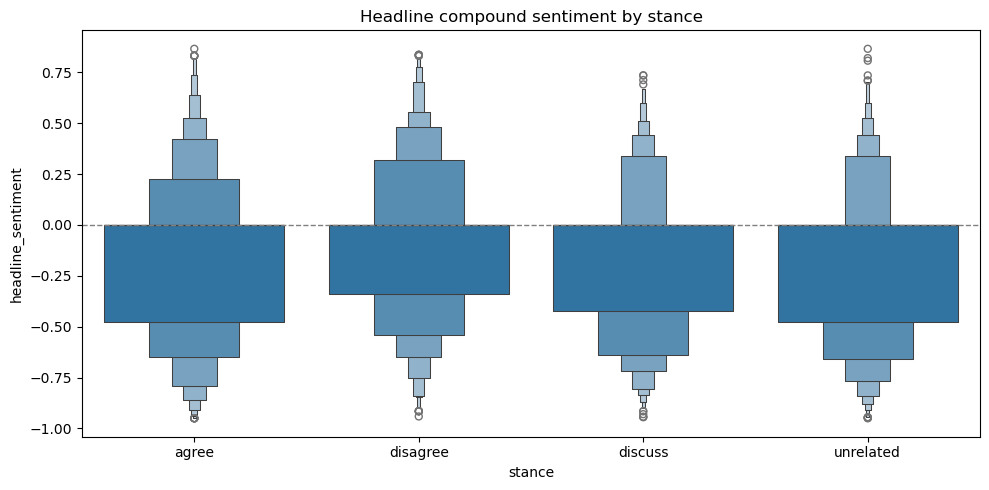

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# e.g. compound in [-1, 1]
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxenplot(data=df_balanced, x="stance", y="headline_sentiment", order=sorted(df_balanced["stance"].unique()))
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Headline compound sentiment by stance")
plt.tight_layout()

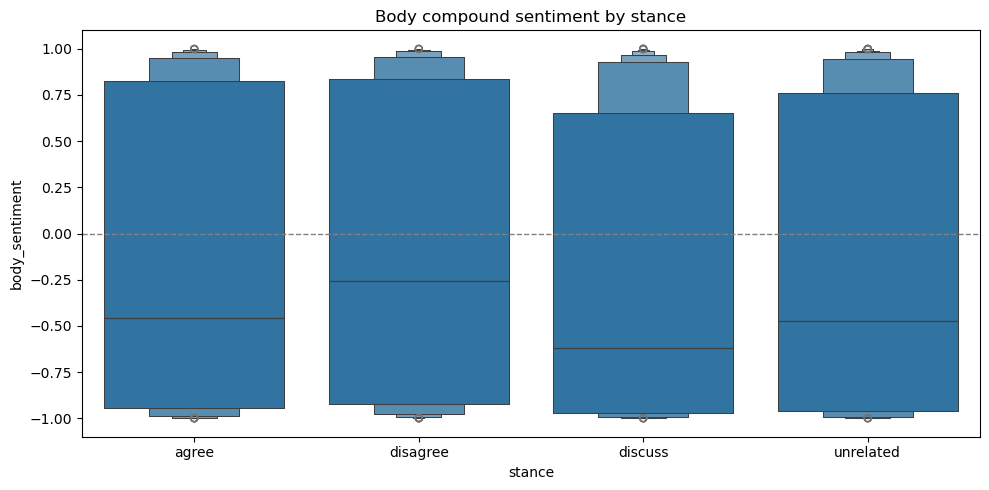

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxenplot(data=df_balanced, x="stance", y="body_sentiment", order=sorted(df_balanced["stance"].unique()))
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Body compound sentiment by stance")
plt.tight_layout()

From these graphs, we can see that not are skewed towards negative sentiment in general, however disagree is slightly less negative compared to others.

And there's little to no deviation in headline sentiments, because most are concentrated towards neutral (0.0).

Text(0.5, 1.0, 'Headline sentiment distributions by stance')

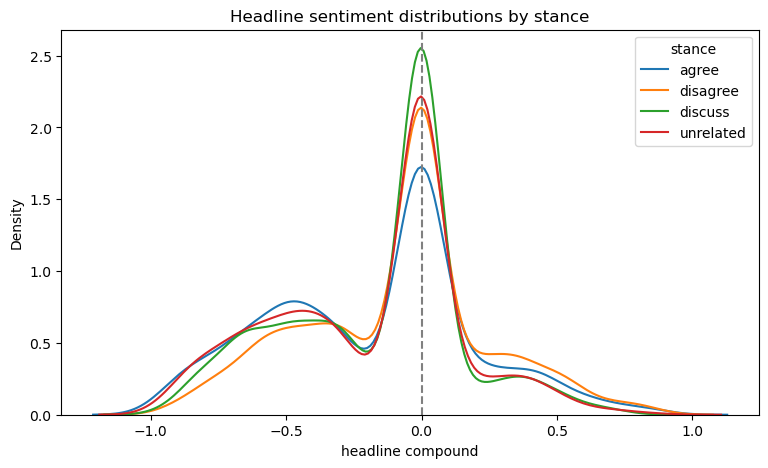

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
for s in sorted(df_balanced["stance"].unique()):
    sns.kdeplot(df_balanced.loc[df_balanced["stance"] == s, "headline_sentiment"], label=s, ax=ax)
plt.axvline(0, color="gray", linestyle="--")
plt.legend(title="stance")
plt.xlabel("headline compound")
plt.title("Headline sentiment distributions by stance")

Text(0.5, 1.0, 'Headline vs body sentiment (subsample)')

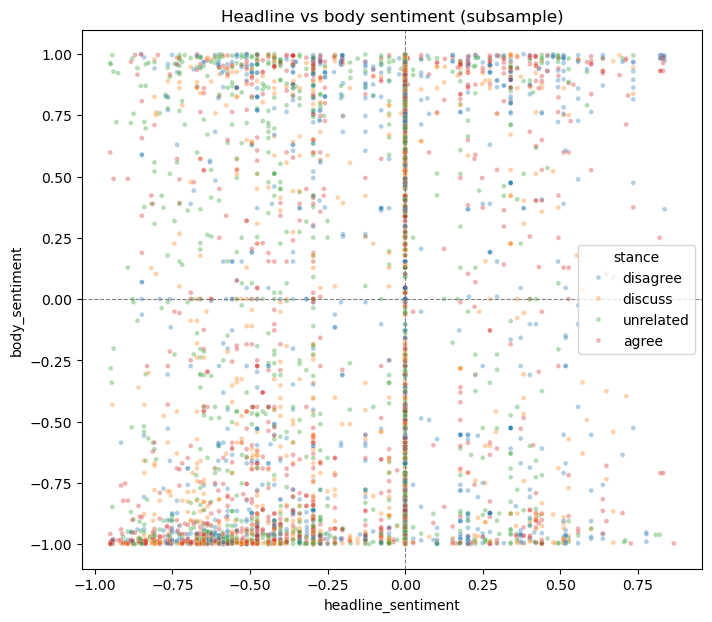

In [21]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.scatterplot(
    data=df_balanced.sample(min(5000, len(df_balanced)), random_state=42),  # subsample if huge
    x="headline_sentiment",
    y="body_sentiment",
    hue="stance",
    alpha=0.35,
    s=12,
    ax=ax,
)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)
plt.title("Headline vs body sentiment (subsample)")

Body sentiment tends to concentrate around the extreme ends, either very positive or very negative.

<Axes: xlabel='stance', ylabel='headline_sentiment'>

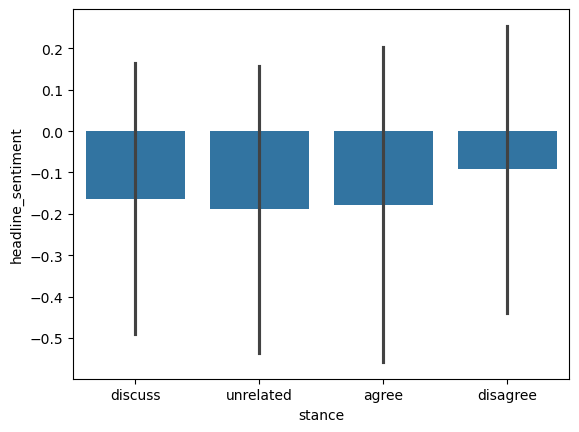

In [24]:
from numpy import amax


g = df_balanced.groupby("stance")[["headline_sentiment", "body_sentiment"]].agg(["mean", "std", "count"])
# then bar plot of means with std error bars — good for slides
sns.barplot(x="stance", y="headline_sentiment", data=df_balanced, estimator="mean", errorbar="sd")

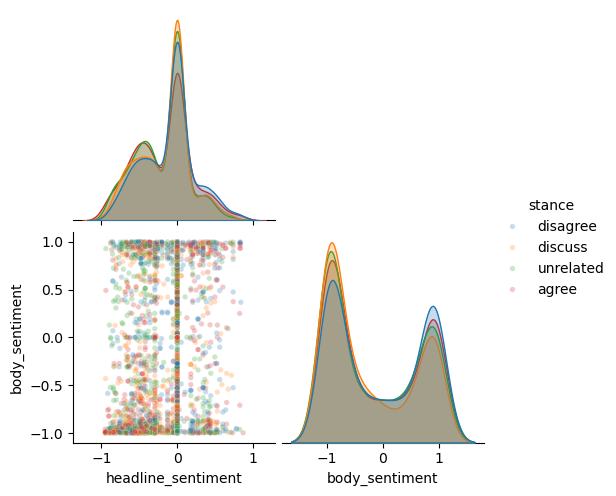

In [25]:
cols = ["headline_sentiment", "body_sentiment"]  # add pos/neg/neu if you have them
sns.pairplot(df_balanced.sample(min(3000, len(df_balanced)), random_state=42),
             vars=cols, hue="stance", corner=True, plot_kws={"alpha": 0.25, "s": 15})

<Axes: xlabel='stance'>

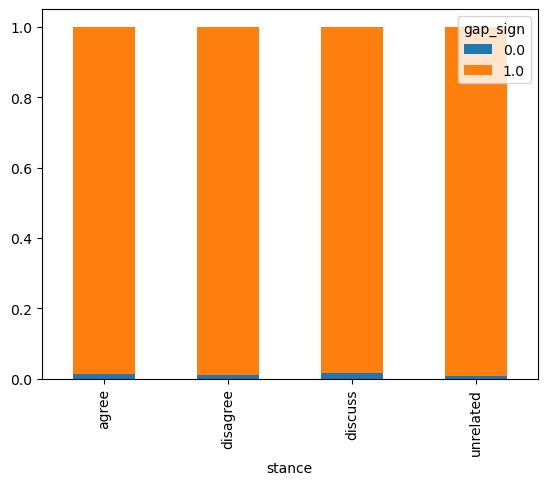

In [27]:
# example: which side is more positive?
df_balanced = df_balanced.copy()
df_balanced["gap_sign"] = np.sign(df_balanced["sentiment_gap"])  # -1, 0, 1

pd.crosstab(df_balanced["stance"], df_balanced["gap_sign"], normalize="index").plot(kind="bar", stacked=True)

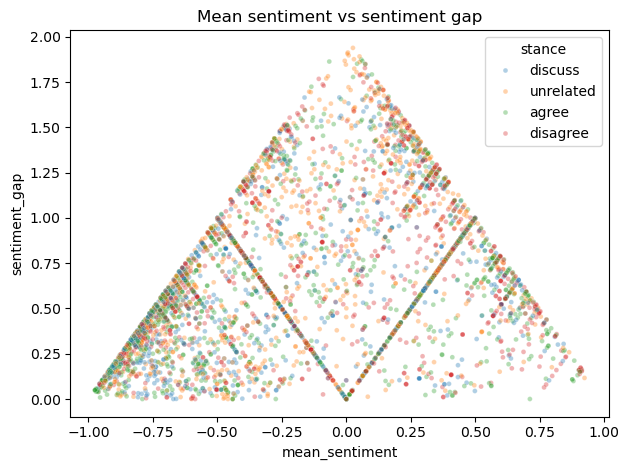

In [ ]:
# df_balanced["mean_sentiment"] = (df_balanced["headline_sentiment"] + df_balanced["body_sentiment"]) / 2
# scatter: x = mean_sentiment, y = sentiment_gap, hue=stance
# sns.scatterplot(
#     data=df_balanced,
#     x="mean_sentiment",
#     y="sentiment_gap",
#     hue="stance",
#     alpha=0.35, s=12)
# plt.title("Mean sentiment vs sentiment gap")
# plt.tight_layout()
# plt.show()

### Text clustering (TF–IDF + SVD + k-means + HAC)

We cluster **headline + truncated body** with the headline repeated twice so framing is not drowned out by long articles. Steps: `TfidfVectorizer` → `TruncatedSVD` → **elbow** (KMeans inertia) and **silhouette** on the same subsample to pick **k** → `KMeans` (`text_cluster`). **HAC** (Ward) on up to 8k points with the same **k**; labels are extended to all rows by nearest centroid in SVD space (`text_cluster_hac`). A **dendrogram** uses a small random subsample for readability. Outputs include stance × cluster heatmaps for both methods.

Silhouette (subsample) by k: {2: 0.0298, 3: 0.0647, 4: 0.051, 5: 0.0679, 6: 0.0778, 7: 0.0837, 8: 0.1089, 9: 0.116, 10: 0.0672, 11: 0.0853, 12: 0.0926, 13: 0.0992, 14: 0.153, 15: 0.11}
Inertia (subsample) by k: {2: 1735.0, 3: 1693.0, 4: 1644.0, 5: 1583.0, 6: 1559.0, 7: 1541.0, 8: 1441.0, 9: 1440.0, 10: 1387.0, 11: 1336.0, 12: 1316.0, 13: 1298.0, 14: 1270.0, 15: 1233.0}
Chosen k (max silhouette): 14


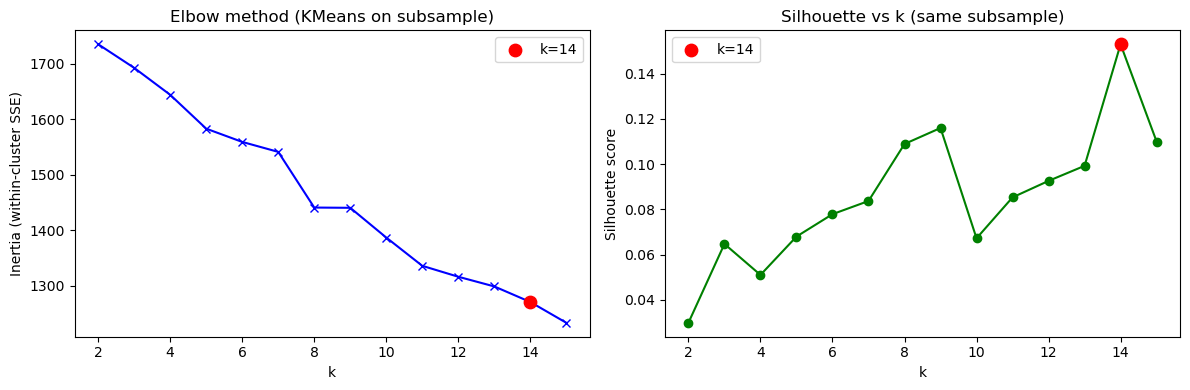

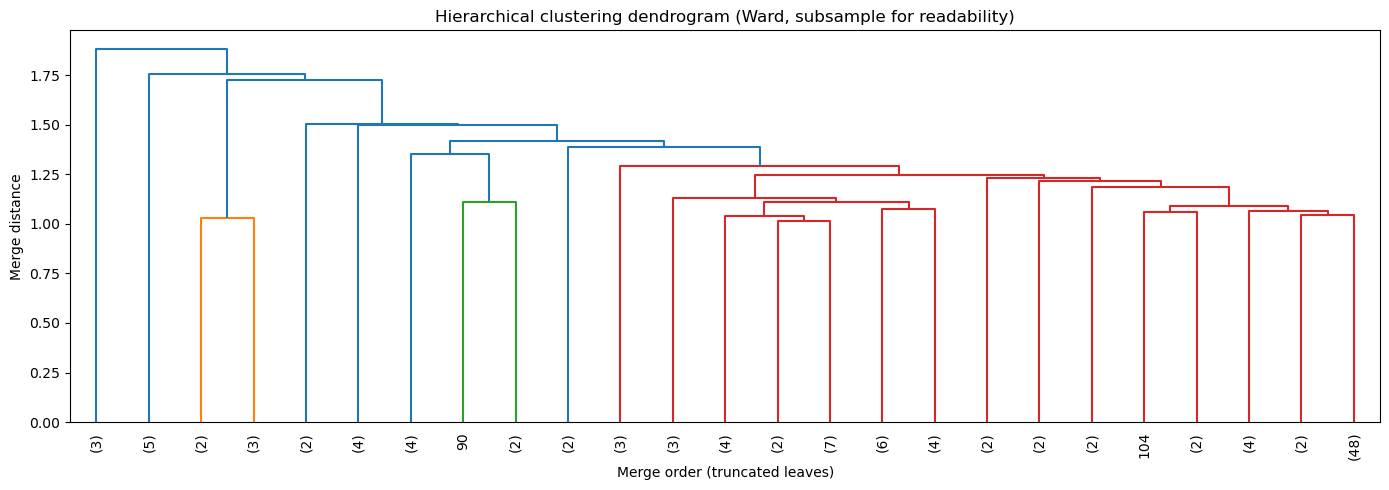


Top TF-IDF terms per cluster (mean weight) — KMeans:
0  |  meteorite, crater, asteroid, nicaragua, nicaraguan, managua, earth, nasa, the nicaraguan, impact, capital, the meteorite
1  |  apple, apple watch, watch, the apple, will, iphone, company, apple is, the company, be, launch, the watch
2  |  that, it, on, is, was, for, he, his, with, as, this, at
3  |  bear, bieber, ringtone, justin bieber, justin, vorozhbitsyn, the bear, bear attack, phone, fisherman, igor, bieber ringtone
4  |  werewolf, argentina, seventh, president, jewish, tawil, godson, the president, seventh son, kirchner, argentina president, adopted
5  |  dulaimi, baghdadi, lebanese, lebanon, al dulaimi, al baghdadi, al, wife, saja, detained, bakr al, abu bakr
6  |  spider, thomas, skin, bali, dylan, burrowed, tropical, tropical spider, scar, dylan thomas, his skin, stomach
7  |  breast, third, third breast, tridevil, woman, surgery, she, jasmine, her, jasmine tridevil, boob, florida
8  |  at, that, cnn, kim, on, rivers,

stance,agree,disagree,discuss,unrelated
text_cluster,,,,
0,0.182,0.532,0.169,0.117
1,0.030,0.019,0.383,0.568
2,0.332,0.226,0.151,0.291
3,0.494,0.202,0.146,0.157
4,0.263,0.622,0.033,0.081
5,0.085,0.488,0.183,0.244
6,0.186,0.571,0.099,0.143
7,0.186,0.600,0.162,0.052
8,0.151,0.192,0.420,0.237



P(stance | cluster) HAC (extended) — rows sum to 1:


stance,agree,disagree,discuss,unrelated
text_cluster_hac,,,,
0,0.187,0.138,0.398,0.278
1,0.303,0.205,0.180,0.311
2,0.186,0.571,0.099,0.143
3,0.159,0.469,0.276,0.097
4,0.405,0.333,0.126,0.135
5,0.186,0.600,0.162,0.052
6,0.083,0.049,0.472,0.396
7,0.182,0.532,0.169,0.117
8,0.066,0.270,0.484,0.180


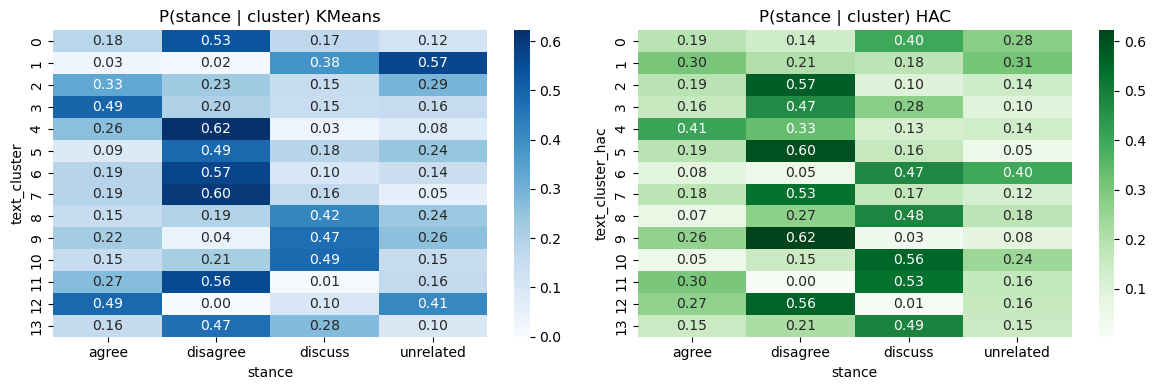

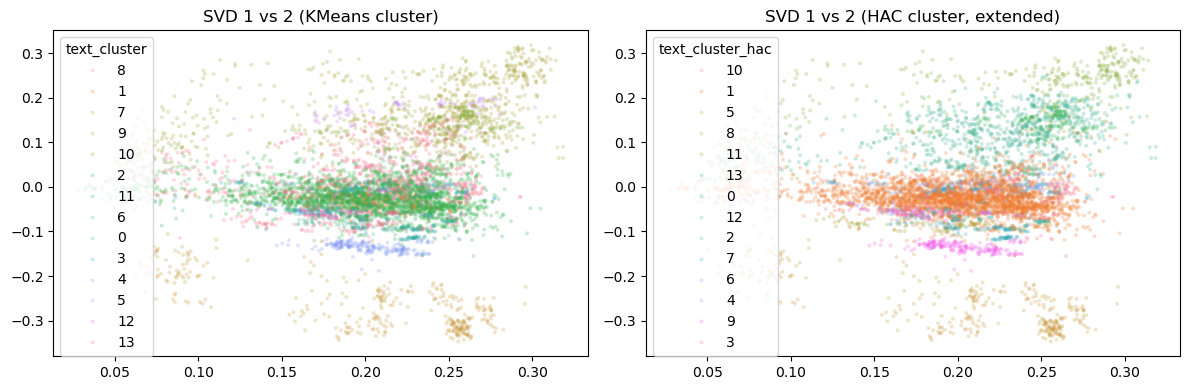

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.environ.setdefault("OMP_NUM_THREADS", "8")
from IPython.display import display
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import cdist


HEAD_REPEATS = 2
BODY_MAX_WORDS = 400
RANDOM_STATE = 42


def _truncate_words(text, max_words=BODY_MAX_WORDS):
    words = str(text).split()
    return " ".join(words[:max_words])


def build_cluster_text(row):
    """Headline repeated so it is not drowned out by long bodies."""
    h = str(row["headline"]).strip()
    b = _truncate_words(row["body"])
    return ((h + " ") * HEAD_REPEATS) + b


df_balanced["_cluster_text"] = df_balanced.apply(build_cluster_text, axis=1)

vectorizer = TfidfVectorizer(
    max_features=12_000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True,
)
X_tfidf = vectorizer.fit_transform(df_balanced["_cluster_text"])

n_svd = min(80, X_tfidf.shape[1] - 1, X_tfidf.shape[0] - 1)
n_svd = max(2, n_svd)
svd = TruncatedSVD(n_components=n_svd, random_state=RANDOM_STATE)
X_svd = svd.fit_transform(X_tfidf)

rng = np.random.default_rng(RANDOM_STATE)
sub_n = min(10_000, X_svd.shape[0])
sub_idx = rng.choice(X_svd.shape[0], size=sub_n, replace=False)
X_sub = X_svd[sub_idx]

k_candidates = list(range(2, 16))
sil_scores = []
inertias = []
for k in k_candidates:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_sub)
    sil_scores.append(silhouette_score(X_sub, labels))
    inertias.append(km.inertia_)

best_k = k_candidates[int(np.argmax(sil_scores))]
print("Silhouette (subsample) by k:", dict(zip(k_candidates, [round(s, 4) for s in sil_scores])))
print("Inertia (subsample) by k:", dict(zip(k_candidates, [round(x, 0) for x in inertias])))
print("Chosen k (max silhouette):", best_k)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_candidates, inertias, "bx-")
axes[0].scatter([best_k], [inertias[k_candidates.index(best_k)]], color="red", s=80, zorder=3, label=f"k={best_k}")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_title("Elbow method (KMeans on subsample)")
axes[0].legend()
axes[1].plot(k_candidates, sil_scores, "go-")
axes[1].scatter([best_k], [sil_scores[k_candidates.index(best_k)]], color="red", s=80, zorder=3, label=f"k={best_k}")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette vs k (same subsample)")
axes[1].legend()
plt.tight_layout()
plt.show()

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df_balanced["text_cluster"] = kmeans.fit_predict(X_svd)

# HAC (Ward): fit on subsample; extend labels to all rows via nearest cluster centroid in SVD space
HAC_MAX = min(8000, X_svd.shape[0])
hac_idx = rng.choice(X_svd.shape[0], size=HAC_MAX, replace=False)
hac = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
labels_hac_sub = hac.fit_predict(X_svd[hac_idx])
centroids_hac = np.vstack(
    [X_svd[hac_idx][labels_hac_sub == c].mean(axis=0) for c in range(best_k)]
)
df_balanced["text_cluster_hac"] = np.argmin(cdist(X_svd, centroids_hac), axis=1)

DEND_N = min(120, HAC_MAX)
dend_idx = rng.choice(hac_idx, size=DEND_N, replace=False)
Z = linkage(X_svd[dend_idx], method="ward")
plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode="lastp", p=25, leaf_rotation=90.0)
plt.title("Hierarchical clustering dendrogram (Ward, subsample for readability)")
plt.xlabel("Merge order (truncated leaves)")
plt.ylabel("Merge distance")
plt.tight_layout()
plt.show()

feature_names = np.array(vectorizer.get_feature_names_out())


def top_terms_for_cluster(cluster_id, top_n=15):
    mask = df_balanced["text_cluster"].values == cluster_id
    if mask.sum() == 0:
        return []
    centroid = np.asarray(X_tfidf[mask].mean(axis=0)).ravel()
    top_ix = np.argsort(-centroid)[:top_n]
    return list(zip(feature_names[top_ix], centroid[top_ix]))


print("\nTop TF-IDF terms per cluster (mean weight) — KMeans:")
for c in range(best_k):
    terms = top_terms_for_cluster(c, top_n=12)
    print(c, " | ", ", ".join(f"{t}" for t, _ in terms))

ct = pd.crosstab(df_balanced["text_cluster"], df_balanced["stance"], normalize="index")
print("\nP(stance | cluster) KMeans — rows sum to 1:")
display(ct.round(3))

ct_hac = pd.crosstab(df_balanced["text_cluster_hac"], df_balanced["stance"], normalize="index")
print("\nP(stance | cluster) HAC (extended) — rows sum to 1:")
display(ct_hac.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues", ax=axes[0])
axes[0].set_title("P(stance | cluster) KMeans")
sns.heatmap(ct_hac, annot=True, fmt=".2f", cmap="Greens", ax=axes[1])
axes[1].set_title("P(stance | cluster) HAC")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(
    x=X_svd[:, 0],
    y=X_svd[:, 1],
    hue=df_balanced["text_cluster"].astype(str),
    alpha=0.25,
    s=8,
    linewidth=0,
    ax=axes[0],
)
axes[0].set_title("SVD 1 vs 2 (KMeans cluster)")
sns.scatterplot(
    x=X_svd[:, 0],
    y=X_svd[:, 1],
    hue=df_balanced["text_cluster_hac"].astype(str),
    alpha=0.25,
    s=8,
    linewidth=0,
    ax=axes[1],
)
axes[1].set_title("SVD 1 vs 2 (HAC cluster, extended)")
plt.tight_layout()
plt.show()

df_balanced.drop(columns=["_cluster_text"], inplace=True)


Keep aside clustering for now in modeling